In [ ]:
!unzip "/content/Hotel Reservations (1).csv.zip" -d "/content/"

Archive:  /content/Hotel Reservations (1).csv.zip
  inflating: /content/Hotel Reservations (1).csv  


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df=pd.read_csv("/content/Hotel Reservations (1).csv")

In [ ]:

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36275 entries, 0 to 36274
Data columns (total 19 columns):
 #   Column                                Non-Null Count  Dtype  
---  ------                                --------------  -----  
 0   Booking_ID                            36275 non-null  object 
 1   no_of_adults                          36275 non-null  int64  
 2   no_of_children                        36275 non-null  int64  
 3   no_of_weekend_nights                  36275 non-null  int64  
 4   no_of_week_nights                     36275 non-null  int64  
 5   type_of_meal_plan                     36275 non-null  object 
 6   required_car_parking_space            36275 non-null  int64  
 7   room_type_reserved                    36275 non-null  object 
 8   lead_time                             36275 non-null  int64  
 9   arrival_year                          36275 non-null  int64  
 10  arrival_month                         36275 non-null  int64  
 11  arrival_date   

In [ ]:
df.head()

,Booking_ID,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,INN00001,2,0,1,2,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled
1,INN00002,2,0,2,3,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled
2,INN00003,1,0,2,1,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled
3,INN00004,2,0,0,2,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled
4,INN00005,2,0,1,1,Not Selected,0,Room_Type 1,48,2018,4,11,Online,0,0,0,94.50,0,Canceled


In [ ]:
df["total_nights"] = (
    df["no_of_weekend_nights"] +
    df["no_of_week_nights"]
)

df.drop(columns=["no_of_weekend_nights","no_of_week_nights"], inplace=True)

In [ ]:
df["no_of_special_requests"].value_counts()

,count
no_of_special_requests,
0,19777
1,11373
2,4364
3,675
4,78
5,8


In [ ]:
df.groupby("booking_status")["lead_time"].describe()

,count,mean,std,min,25%,50%,75%,max
booking_status,,,,,,,,
Canceled,11885.0,139.215482,98.947731,0.0,55.0,122.0,205.0,443.0
Not_Canceled,24390.0,58.927224,64.028714,0.0,10.0,39.0,86.0,386.0


In [ ]:
df_corr = df.copy()

df_corr["booking_status"] = df_corr["booking_status"].map({
    "Not_Canceled": 0,
    "Canceled": 1
})

corr_matrix = df_corr.corr(numeric_only=True)

corr_matrix["booking_status"].sort_values(ascending=False)

,booking_status
booking_status,1.000000
lead_time,0.438538
arrival_year,0.179529
avg_price_per_room,0.142569
total_nights,0.103475
no_of_adults,0.086920
no_of_children,0.033078
arrival_date,0.010629
arrival_month,-0.011233
no_of_previous_cancellations,-0.033728


In [ ]:
df.groupby("booking_status")["no_of_special_requests"].mean()

,no_of_special_requests
booking_status,
Canceled,0.334623
Not_Canceled,0.758549


In [ ]:
df["no_of_adults"].value_counts()

,count
no_of_adults,
2,26108
1,7695
3,2317
0,139
4,16


In [ ]:
df[df["no_of_adults"] == 0]

,Booking_ID,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights
32,INN00033,0,2,Meal Plan 1,0,Room_Type 2,56,2018,12,7,Online,0,0,0,82.44,1,Not_Canceled,3
287,INN00288,0,2,Meal Plan 1,0,Room_Type 1,68,2018,4,24,Online,0,0,0,108.38,1,Canceled,4
653,INN00654,0,2,Meal Plan 1,0,Room_Type 2,78,2018,8,19,Online,0,0,0,115.68,1,Not_Canceled,3
937,INN00938,0,2,Meal Plan 1,0,Room_Type 2,40,2018,1,14,Online,0,0,0,6.67,1,Not_Canceled,3
954,INN00955,0,2,Meal Plan 1,0,Room_Type 2,92,2018,10,29,Online,0,0,0,81.50,2,Not_Canceled,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
34720,INN34721,0,2,Meal Plan 1,0,Room_Type 2,76,2018,9,21,Online,0,0,0,127.38,3,Not_Canceled,3
34730,INN34731,0,2,Meal Plan 1,0,Room_Type 2,178,2018,8,27,Online,0,0,0,88.77,0,Canceled,2
34890,INN34891,0,2,Meal Plan 1,0,Room_Type 2,31,2018,9,16,Online,0,0,0,124.25,2,Not_Canceled,4
35691,INN35692,0,2,Meal Plan 1,0,Room_Type 2,75,2018,3,19,Online,0,0,0,78.00,0,Canceled,3


In [ ]:
df[df["no_of_adults"] == 0][
    ["no_of_adults",
     "no_of_children",
     "booking_status"]
].head(20)

,no_of_adults,no_of_children,booking_status
32,0,2,Not_Canceled
287,0,2,Canceled
653,0,2,Not_Canceled
937,0,2,Not_Canceled
954,0,2,Not_Canceled
1395,0,1,Not_Canceled
1660,0,2,Not_Canceled
2308,0,2,Not_Canceled
2331,0,2,Not_Canceled
2336,0,2,Not_Canceled


In [ ]:
df[df["no_of_adults"] == 0]["booking_status"].value_counts(normalize=True)

,proportion
booking_status,
Not_Canceled,0.683453
Canceled,0.316547


In [ ]:
df[df["no_of_adults"] > 0]["booking_status"].value_counts(normalize=True)

,proportion
booking_status,
Not_Canceled,0.672321
Canceled,0.327679


In [ ]:
df_corr = df.copy()

In [ ]:
df_corr['booking_status']=df_corr["booking_status"].map({"Not_Canceled": 0, "Canceled": 1})
corr_matrix=df_corr.corr(numeric_only=True)
corr_matrix

,no_of_adults,no_of_children,required_car_parking_space,lead_time,arrival_year,arrival_month,arrival_date,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights
no_of_adults,1.000000,-0.019787,0.011429,0.097287,0.076719,0.021841,0.026338,-0.192277,-0.047426,-0.119166,0.296886,0.189401,0.086920,0.133803
no_of_children,-0.019787,1.000000,0.034244,-0.047091,0.045983,-0.003076,0.025482,-0.036348,-0.016390,-0.021189,0.337728,0.124486,0.033078,0.033644
required_car_parking_space,0.011429,0.034244,1.000000,-0.066445,0.015684,-0.015505,-0.000037,0.110909,0.027106,0.063810,0.061304,0.087922,-0.086185,-0.053704
lead_time,0.097287,-0.047091,-0.066445,1.000000,0.143439,0.136814,0.006479,-0.135984,-0.045723,-0.078137,-0.062596,-0.101645,0.438538,0.140934
arrival_year,0.076719,0.045983,0.015684,0.143439,1.000000,-0.339689,0.018849,-0.018175,0.003919,0.026422,0.178605,0.053205,0.179529,0.052795
arrival_month,0.021841,-0.003076,-0.015505,0.136814,-0.339689,1.000000,-0.042780,0.000341,-0.038615,-0.010718,0.054423,0.110552,-0.011233,0.024703
arrival_date,0.026338,0.025482,-0.000037,0.006479,0.018849,-0.042780,1.000000,-0.015949,-0.012542,-0.001498,0.017898,0.018352,0.010629,0.005960
repeated_guest,-0.192277,-0.036348,0.110909,-0.135984,-0.018175,0.000341,-0.015949,1.000000,0.390810,0.539156,-0.174900,-0.011820,-0.107287,-0.111525
no_of_previous_cancellations,-0.047426,-0.016390,0.027106,-0.045723,0.003919,-0.038615,-0.012542,0.390810,1.000000,0.468147,-0.063340,-0.003317,-0.033728,-0.033849
no_of_previous_bookings_not_canceled,-0.119166,-0.021189,0.063810,-0.078137,0.026422,-0.010718,-0.001498,0.539156,0.468147,1.000000,-0.113684,0.027377,-0.060179,-0.051807


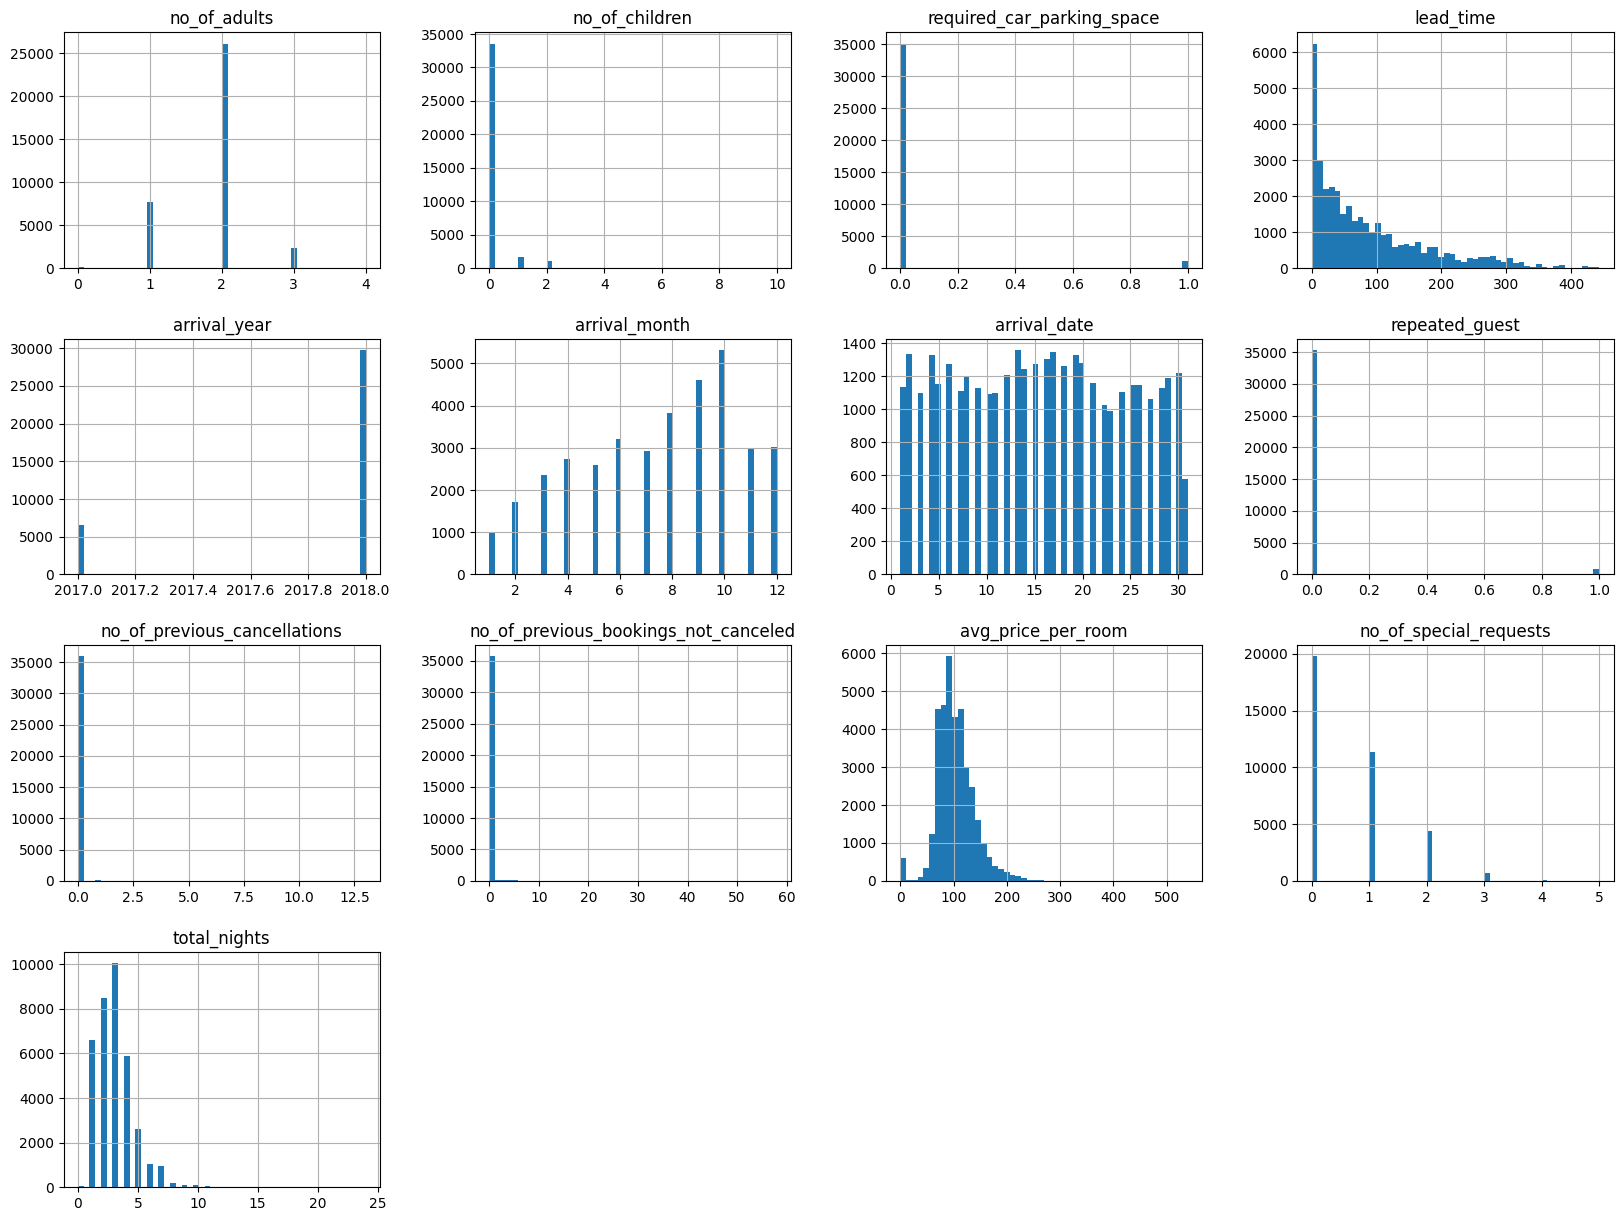

In [ ]:
df.hist(bins=50, figsize=(20,15))
plt.show()

In [ ]:
def split_train_test(data, test_ratio):
  shuffeledindices=np.random.permutation(len(data))
  test_set_size=int(len(data)*test_ratio)
  train_set=shuffeledindices[:test_set_size]
  test_set=shuffeledindices[test_set_size:]
  return   data.iloc[test_set] , data.iloc[train_set]


In [ ]:
train_set, test_set=split_train_test(df, 0.2)

In [ ]:
train_set.value_counts()

,,,,,,,,,,,,,,,,,,count
Booking_ID,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,
INN36275,2,0,Meal Plan 1,0,Room_Type 1,207,2018,12,30,Offline,0,0,0,161.67,0,Not_Canceled,3,1
INN00001,2,0,Meal Plan 1,0,Room_Type 1,224,2017,10,2,Offline,0,0,0,65.00,0,Not_Canceled,3,1
INN00002,2,0,Not Selected,0,Room_Type 1,5,2018,11,6,Online,0,0,0,106.68,1,Not_Canceled,5,1
INN00003,1,0,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled,3,1
INN00004,2,0,Meal Plan 1,0,Room_Type 1,211,2018,5,20,Online,0,0,0,100.00,0,Canceled,2,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
INN00023,2,0,Meal Plan 1,0,Room_Type 1,2,2018,3,20,Offline,0,0,0,85.00,0,Not_Canceled,6,1
INN00022,1,0,Meal Plan 1,0,Room_Type 1,122,2018,11,25,Corporate,0,0,0,67.00,0,Not_Canceled,1,1
INN00021,2,0,Meal Plan 1,0,Room_Type 1,99,2017,10,30,Online,0,0,0,65.00,0,Canceled,4,1


In [ ]:
df["total_previous_bookings"] = (
    df["no_of_previous_cancellations"] +
    df["no_of_previous_bookings_not_canceled"]
)


In [ ]:
df["family"] = (
    df["no_of_adults"] +
    df["no_of_children"]
)
df["cancellation_ratio"] = (
    df["no_of_previous_cancellations"] /
    (df["total_previous_bookings"] + 1)

  )
df["price_per_guest"] = (
    df["avg_price_per_room"] /
    (df["family"] + 1)
)
df["booking_urgency"] = (
    df["lead_time"] /
    (df["total_nights"] + 1)
)

In [ ]:
pd.crosstab(
    df["room_type_reserved"],
    df["booking_status"],
    normalize="index"
)


booking_status,Canceled,Not_Canceled
room_type_reserved,,
Room_Type 1,0.322503,0.677497
Room_Type 2,0.329480,0.670520
Room_Type 3,0.285714,0.714286
Room_Type 4,0.341588,0.658412
Room_Type 5,0.271698,0.728302
Room_Type 6,0.420290,0.579710
Room_Type 7,0.227848,0.772152


In [ ]:
train_set.groupby("booking_status")["repeated_guest"].mean()

,repeated_guest
booking_status,
Canceled,0.001259
Not_Canceled,0.037143


In [ ]:
pd.crosstab(
    df["market_segment_type"],
    df["booking_status"],
    normalize="index"
)

booking_status,Canceled,Not_Canceled
market_segment_type,,
Aviation,0.296000,0.704000
Complementary,0.000000,1.000000
Corporate,0.109073,0.890927
Offline,0.299487,0.700513
Online,0.365081,0.634919


In [ ]:
df["market_segment_type"].value_counts()

,count
market_segment_type,
Online,23214
Offline,10528
Corporate,2017
Complementary,391
Aviation,125


In [ ]:
df["booking_status"].value_counts()

,count
booking_status,
Not_Canceled,24390
Canceled,11885


In [ ]:
from sklearn.model_selection import train_test_split

In [ ]:
df

,Booking_ID,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,...,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,total_previous_bookings,family,cancellation_ratio,price_per_guest,booking_urgency
0,INN00001,2,0,Meal Plan 1,0,Room_Type 1,224,2017,10,2,...,0,65.00,0,Not_Canceled,3,0,2,0.0,21.666667,56.000000
1,INN00002,2,0,Not Selected,0,Room_Type 1,5,2018,11,6,...,0,106.68,1,Not_Canceled,5,0,2,0.0,35.560000,0.833333
2,INN00003,1,0,Meal Plan 1,0,Room_Type 1,1,2018,2,28,...,0,60.00,0,Canceled,3,0,1,0.0,30.000000,0.250000
3,INN00004,2,0,Meal Plan 1,0,Room_Type 1,211,2018,5,20,...,0,100.00,0,Canceled,2,0,2,0.0,33.333333,70.333333
4,INN00005,2,0,Not Selected,0,Room_Type 1,48,2018,4,11,...,0,94.50,0,Canceled,2,0,2,0.0,31.500000,16.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,Meal Plan 1,0,Room_Type 4,85,2018,8,3,...,0,167.80,1,Not_Canceled,8,0,3,0.0,41.950000,9.444444
36271,INN36272,2,0,Meal Plan 1,0,Room_Type 1,228,2018,10,17,...,0,90.95,2,Canceled,4,0,2,0.0,30.316667,45.600000
36272,INN36273,2,0,Meal Plan 1,0,Room_Type 1,148,2018,7,1,...,0,98.39,2,Not_Canceled,8,0,2,0.0,32.796667,16.444444
36273,INN36274,2,0,Not Selected,0,Room_Type 1,63,2018,4,21,...,0,94.50,0,Canceled,3,0,2,0.0,31.500000,15.750000


In [ ]:
for col in [
    "total_nights",
    "family",
    "price_per_guest",
    "booking_urgency",
    "cancellation_ratio",
    "total_previous_bookings"
]:
    print("\n", col)
    print(df.groupby("booking_status")[col].mean())


 total_nights
booking_status
Canceled        3.279764
Not_Canceled    2.886019
Name: total_nights, dtype: float64

 family
booking_status
Canceled        2.033908
Not_Canceled    1.909471
Name: family, dtype: float64

 price_per_guest
booking_status
Canceled        37.241689
Not_Canceled    35.078989
Name: price_per_guest, dtype: float64

 booking_urgency
booking_status
Canceled        37.597468
Not_Canceled    15.712571
Name: booking_urgency, dtype: float64

 cancellation_ratio
booking_status
Canceled        0.000711
Not_Canceled    0.004099
Name: cancellation_ratio, dtype: float64

 total_previous_bookings
booking_status
Canceled        0.007741
Not_Canceled    0.259123
Name: total_previous_bookings, dtype: float64


In [ ]:
y=df['booking_status']
X=df[[
    "no_of_adults",
    "no_of_children",

    "type_of_meal_plan",
    "required_car_parking_space",
    "room_type_reserved",

    "lead_time",

    "arrival_month",
    "arrival_date",

    "market_segment_type",

    "repeated_guest",
    "no_of_previous_cancellations",
    "no_of_previous_bookings_not_canceled",

    "avg_price_per_room",
    "no_of_special_requests",

    "total_nights",
    "family",
    "total_previous_bookings",
    "price_per_guest",
    "booking_urgency"
]]

In [ ]:
df

,Booking_ID,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,...,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights,total_previous_bookings,family,cancellation_ratio,price_per_guest,booking_urgency
0,INN00001,2,0,Meal Plan 1,0,Room_Type 1,224,2017,10,2,...,0,65.00,0,Not_Canceled,3,0,2,0.0,21.666667,56.000000
1,INN00002,2,0,Not Selected,0,Room_Type 1,5,2018,11,6,...,0,106.68,1,Not_Canceled,5,0,2,0.0,35.560000,0.833333
2,INN00003,1,0,Meal Plan 1,0,Room_Type 1,1,2018,2,28,...,0,60.00,0,Canceled,3,0,1,0.0,30.000000,0.250000
3,INN00004,2,0,Meal Plan 1,0,Room_Type 1,211,2018,5,20,...,0,100.00,0,Canceled,2,0,2,0.0,33.333333,70.333333
4,INN00005,2,0,Not Selected,0,Room_Type 1,48,2018,4,11,...,0,94.50,0,Canceled,2,0,2,0.0,31.500000,16.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,Meal Plan 1,0,Room_Type 4,85,2018,8,3,...,0,167.80,1,Not_Canceled,8,0,3,0.0,41.950000,9.444444
36271,INN36272,2,0,Meal Plan 1,0,Room_Type 1,228,2018,10,17,...,0,90.95,2,Canceled,4,0,2,0.0,30.316667,45.600000
36272,INN36273,2,0,Meal Plan 1,0,Room_Type 1,148,2018,7,1,...,0,98.39,2,Not_Canceled,8,0,2,0.0,32.796667,16.444444
36273,INN36274,2,0,Not Selected,0,Room_Type 1,63,2018,4,21,...,0,94.50,0,Canceled,3,0,2,0.0,31.500000,15.750000


In [ ]:
cat_features = [
    "type_of_meal_plan",
    "room_type_reserved",
    "market_segment_type"

]
num_features = [
    "no_of_adults",
    "no_of_children",
    "required_car_parking_space",
    "lead_time",
    "arrival_month",
    "arrival_date",
    "repeated_guest",
    "no_of_previous_cancellations",
    "no_of_previous_bookings_not_canceled",
    "avg_price_per_room",
    "no_of_special_requests",
    "total_nights",
    "family",
    "total_previous_bookings",
    "price_per_guest",
    "booking_urgency"
]

In [ ]:
X = df
y=y

In [ ]:

X


,Booking_ID,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,...,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,total_nights,total_previous_bookings,family,cancellation_ratio,price_per_guest,booking_urgency
0,INN00001,2,0,Meal Plan 1,0,Room_Type 1,224,2017,10,2,...,0,0,65.00,0,3,0,2,0.0,21.666667,56.000000
1,INN00002,2,0,Not Selected,0,Room_Type 1,5,2018,11,6,...,0,0,106.68,1,5,0,2,0.0,35.560000,0.833333
2,INN00003,1,0,Meal Plan 1,0,Room_Type 1,1,2018,2,28,...,0,0,60.00,0,3,0,1,0.0,30.000000,0.250000
3,INN00004,2,0,Meal Plan 1,0,Room_Type 1,211,2018,5,20,...,0,0,100.00,0,2,0,2,0.0,33.333333,70.333333
4,INN00005,2,0,Not Selected,0,Room_Type 1,48,2018,4,11,...,0,0,94.50,0,2,0,2,0.0,31.500000,16.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,Meal Plan 1,0,Room_Type 4,85,2018,8,3,...,0,0,167.80,1,8,0,3,0.0,41.950000,9.444444
36271,INN36272,2,0,Meal Plan 1,0,Room_Type 1,228,2018,10,17,...,0,0,90.95,2,4,0,2,0.0,30.316667,45.600000
36272,INN36273,2,0,Meal Plan 1,0,Room_Type 1,148,2018,7,1,...,0,0,98.39,2,8,0,2,0.0,32.796667,16.444444
36273,INN36274,2,0,Not Selected,0,Room_Type 1,63,2018,4,21,...,0,0,94.50,0,3,0,2,0.0,31.500000,15.750000


In [ ]:
y

,booking_status
0,Not_Canceled
1,Not_Canceled
2,Canceled
3,Canceled
4,Canceled
...,...
36270,Not_Canceled
36271,Canceled
36272,Not_Canceled
36273,Canceled


In [ ]:
test_set

,Booking_ID,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status,total_nights
32037,INN32038,2,0,Meal Plan 1,0,Room_Type 1,47,2018,6,2,Online,0,0,0,126.90,1,Not_Canceled,1
35285,INN35286,1,0,Meal Plan 1,0,Room_Type 1,49,2018,4,19,Online,0,0,0,90.90,1,Not_Canceled,1
30153,INN30154,2,0,Meal Plan 1,0,Room_Type 1,308,2018,11,25,Offline,0,0,0,52.00,0,Canceled,2
18832,INN18833,2,0,Meal Plan 1,0,Room_Type 1,317,2018,9,15,Offline,0,0,0,120.00,0,Canceled,2
6026,INN06027,2,0,Meal Plan 1,0,Room_Type 2,330,2018,10,14,Online,0,0,0,106.70,1,Canceled,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3626,INN03627,1,0,Meal Plan 1,0,Room_Type 1,1,2018,2,28,Online,0,0,0,60.00,0,Canceled,3
6124,INN06125,2,0,Meal Plan 1,0,Room_Type 1,271,2018,9,21,Online,0,0,0,101.33,1,Canceled,3
20579,INN20580,1,0,Meal Plan 1,0,Room_Type 1,119,2018,4,15,Online,0,0,0,90.90,0,Not_Canceled,2
1870,INN01871,2,1,Meal Plan 1,0,Room_Type 1,34,2018,10,26,Offline,0,0,0,100.00,0,Not_Canceled,3


In [ ]:
df

,Booking_ID,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,...,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,total_nights,total_previous_bookings,family,cancellation_ratio,price_per_guest,booking_urgency
0,INN00001,2,0,Meal Plan 1,0,Room_Type 1,224,2017,10,2,...,0,0,65.00,0,3,0,2,0.0,21.666667,56.000000
1,INN00002,2,0,Not Selected,0,Room_Type 1,5,2018,11,6,...,0,0,106.68,1,5,0,2,0.0,35.560000,0.833333
2,INN00003,1,0,Meal Plan 1,0,Room_Type 1,1,2018,2,28,...,0,0,60.00,0,3,0,1,0.0,30.000000,0.250000
3,INN00004,2,0,Meal Plan 1,0,Room_Type 1,211,2018,5,20,...,0,0,100.00,0,2,0,2,0.0,33.333333,70.333333
4,INN00005,2,0,Not Selected,0,Room_Type 1,48,2018,4,11,...,0,0,94.50,0,2,0,2,0.0,31.500000,16.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,Meal Plan 1,0,Room_Type 4,85,2018,8,3,...,0,0,167.80,1,8,0,3,0.0,41.950000,9.444444
36271,INN36272,2,0,Meal Plan 1,0,Room_Type 1,228,2018,10,17,...,0,0,90.95,2,4,0,2,0.0,30.316667,45.600000
36272,INN36273,2,0,Meal Plan 1,0,Room_Type 1,148,2018,7,1,...,0,0,98.39,2,8,0,2,0.0,32.796667,16.444444
36273,INN36274,2,0,Not Selected,0,Room_Type 1,63,2018,4,21,...,0,0,94.50,0,3,0,2,0.0,31.500000,15.750000


In [ ]:
from sklearn.model_selection import StratifiedShuffleSplit
split = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in split.split(X, y):
    strat_train_set = X.loc[train_index]
    strat_test_set = X.loc[test_index]

In [ ]:
strat_train_set

,Booking_ID,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,...,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,total_nights,total_previous_bookings,family,cancellation_ratio,price_per_guest,booking_urgency
9078,INN09079,2,0,Meal Plan 1,0,Room_Type 1,273,2018,5,13,...,0,0,95.00,0,3,0,2,0.0,31.666667,68.250000
36042,INN36043,2,0,Meal Plan 1,0,Room_Type 1,158,2018,6,30,...,0,0,90.95,1,4,0,2,0.0,30.316667,31.600000
5929,INN05930,2,0,Meal Plan 1,0,Room_Type 1,59,2018,11,26,...,0,0,93.60,1,3,0,2,0.0,31.200000,14.750000
6928,INN06929,1,0,Meal Plan 1,0,Room_Type 1,5,2018,10,25,...,0,0,95.00,0,2,0,1,0.0,47.500000,1.666667
34607,INN34608,2,2,Meal Plan 1,0,Room_Type 6,54,2018,4,29,...,0,0,187.85,0,6,0,4,0.0,37.570000,7.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6705,INN06706,2,1,Meal Plan 1,0,Room_Type 4,91,2018,5,13,...,0,0,140.40,0,3,0,3,0.0,35.100000,22.750000
2816,INN02817,2,0,Meal Plan 1,0,Room_Type 1,63,2018,8,9,...,0,0,144.10,0,3,0,2,0.0,48.033333,15.750000
5812,INN05813,2,0,Meal Plan 1,0,Room_Type 1,16,2017,10,1,...,0,0,107.00,0,2,0,2,0.0,35.666667,5.333333
4263,INN04264,1,0,Meal Plan 2,0,Room_Type 1,273,2017,7,17,...,0,0,87.00,0,2,0,1,0.0,43.500000,91.000000


In [ ]:
strat_test_set

,Booking_ID,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,...,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,total_nights,total_previous_bookings,family,cancellation_ratio,price_per_guest,booking_urgency
10010,INN10011,3,0,Meal Plan 1,0,Room_Type 1,165,2018,8,12,...,0,0,146.70,0,3,0,3,0.0,36.675000,41.250000
11433,INN11434,2,0,Meal Plan 1,0,Room_Type 1,4,2018,9,15,...,0,0,169.00,0,1,0,2,0.0,56.333333,2.000000
21619,INN21620,2,0,Meal Plan 1,0,Room_Type 1,59,2018,6,22,...,0,0,99.90,2,2,0,2,0.0,33.300000,19.666667
26404,INN26405,1,0,Meal Plan 1,0,Room_Type 4,28,2018,6,14,...,0,0,108.42,1,3,0,1,0.0,54.210000,7.000000
23444,INN23445,1,0,Meal Plan 2,0,Room_Type 1,74,2017,9,18,...,0,0,87.00,0,2,0,1,0.0,43.500000,24.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16779,INN16780,1,0,Meal Plan 1,0,Room_Type 1,81,2018,6,23,...,0,0,90.90,0,1,0,1,0.0,45.450000,40.500000
19187,INN19188,2,0,Not Selected,1,Room_Type 1,120,2018,5,2,...,0,0,103.50,1,2,0,2,0.0,34.500000,40.000000
34656,INN34657,2,0,Meal Plan 1,0,Room_Type 1,122,2018,4,15,...,0,0,85.00,0,2,0,2,0.0,28.333333,40.666667
11033,INN11034,2,0,Meal Plan 1,0,Room_Type 1,276,2018,5,13,...,0,0,61.00,0,5,0,2,0.0,20.333333,46.000000


In [ ]:
strat_train_set = strat_train_set.drop("Booking_ID", axis=1)
strat_test_set = strat_test_set.drop("Booking_ID", axis=1)

In [ ]:
hotel = strat_train_set.copy()

In [ ]:
hotel

,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,...,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,total_nights,total_previous_bookings,family,cancellation_ratio,price_per_guest,booking_urgency
9078,2,0,Meal Plan 1,0,Room_Type 1,273,2018,5,13,Offline,...,0,0,95.00,0,3,0,2,0.0,31.666667,68.250000
36042,2,0,Meal Plan 1,0,Room_Type 1,158,2018,6,30,Online,...,0,0,90.95,1,4,0,2,0.0,30.316667,31.600000
5929,2,0,Meal Plan 1,0,Room_Type 1,59,2018,11,26,Online,...,0,0,93.60,1,3,0,2,0.0,31.200000,14.750000
6928,1,0,Meal Plan 1,0,Room_Type 1,5,2018,10,25,Aviation,...,0,0,95.00,0,2,0,1,0.0,47.500000,1.666667
34607,2,2,Meal Plan 1,0,Room_Type 6,54,2018,4,29,Online,...,0,0,187.85,0,6,0,4,0.0,37.570000,7.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6705,2,1,Meal Plan 1,0,Room_Type 4,91,2018,5,13,Online,...,0,0,140.40,0,3,0,3,0.0,35.100000,22.750000
2816,2,0,Meal Plan 1,0,Room_Type 1,63,2018,8,9,Online,...,0,0,144.10,0,3,0,2,0.0,48.033333,15.750000
5812,2,0,Meal Plan 1,0,Room_Type 1,16,2017,10,1,Online,...,0,0,107.00,0,2,0,2,0.0,35.666667,5.333333
4263,1,0,Meal Plan 2,0,Room_Type 1,273,2017,7,17,Offline,...,0,0,87.00,0,2,0,1,0.0,43.500000,91.000000


In [ ]:
hotel_X = hotel

hotel_y =y

In [ ]:
hotel_X

,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,...,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,total_nights,total_previous_bookings,family,cancellation_ratio,price_per_guest,booking_urgency
9078,2,0,Meal Plan 1,0,Room_Type 1,273,2018,5,13,Offline,...,0,0,95.00,0,3,0,2,0.0,31.666667,68.250000
36042,2,0,Meal Plan 1,0,Room_Type 1,158,2018,6,30,Online,...,0,0,90.95,1,4,0,2,0.0,30.316667,31.600000
5929,2,0,Meal Plan 1,0,Room_Type 1,59,2018,11,26,Online,...,0,0,93.60,1,3,0,2,0.0,31.200000,14.750000
6928,1,0,Meal Plan 1,0,Room_Type 1,5,2018,10,25,Aviation,...,0,0,95.00,0,2,0,1,0.0,47.500000,1.666667
34607,2,2,Meal Plan 1,0,Room_Type 6,54,2018,4,29,Online,...,0,0,187.85,0,6,0,4,0.0,37.570000,7.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6705,2,1,Meal Plan 1,0,Room_Type 4,91,2018,5,13,Online,...,0,0,140.40,0,3,0,3,0.0,35.100000,22.750000
2816,2,0,Meal Plan 1,0,Room_Type 1,63,2018,8,9,Online,...,0,0,144.10,0,3,0,2,0.0,48.033333,15.750000
5812,2,0,Meal Plan 1,0,Room_Type 1,16,2017,10,1,Online,...,0,0,107.00,0,2,0,2,0.0,35.666667,5.333333
4263,1,0,Meal Plan 2,0,Room_Type 1,273,2017,7,17,Offline,...,0,0,87.00,0,2,0,1,0.0,43.500000,91.000000


In [ ]:
hotel_y

,booking_status
0,Not_Canceled
1,Not_Canceled
2,Canceled
3,Canceled
4,Canceled
...,...
36270,Not_Canceled
36271,Canceled
36272,Not_Canceled
36273,Canceled


In [ ]:
hotel_X = strat_train_set.copy()
hotel_y = y.iloc[train_index].copy()

In [ ]:
strat_test_set

,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,...,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,total_nights,total_previous_bookings,family,cancellation_ratio,price_per_guest,booking_urgency
10010,3,0,Meal Plan 1,0,Room_Type 1,165,2018,8,12,Online,...,0,0,146.70,0,3,0,3,0.0,36.675000,41.250000
11433,2,0,Meal Plan 1,0,Room_Type 1,4,2018,9,15,Online,...,0,0,169.00,0,1,0,2,0.0,56.333333,2.000000
21619,2,0,Meal Plan 1,0,Room_Type 1,59,2018,6,22,Online,...,0,0,99.90,2,2,0,2,0.0,33.300000,19.666667
26404,1,0,Meal Plan 1,0,Room_Type 4,28,2018,6,14,Online,...,0,0,108.42,1,3,0,1,0.0,54.210000,7.000000
23444,1,0,Meal Plan 2,0,Room_Type 1,74,2017,9,18,Offline,...,0,0,87.00,0,2,0,1,0.0,43.500000,24.666667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
16779,1,0,Meal Plan 1,0,Room_Type 1,81,2018,6,23,Online,...,0,0,90.90,0,1,0,1,0.0,45.450000,40.500000
19187,2,0,Not Selected,1,Room_Type 1,120,2018,5,2,Online,...,0,0,103.50,1,2,0,2,0.0,34.500000,40.000000
34656,2,0,Meal Plan 1,0,Room_Type 1,122,2018,4,15,Offline,...,0,0,85.00,0,2,0,2,0.0,28.333333,40.666667
11033,2,0,Meal Plan 1,0,Room_Type 1,276,2018,5,13,Offline,...,0,0,61.00,0,5,0,2,0.0,20.333333,46.000000


In [ ]:
hotel_y

,booking_status
9078,NaN
36042,NaN
5929,NaN
6928,NaN
34607,NaN
...,...
6705,NaN
2816,NaN
5812,NaN
4263,NaN


In [ ]:
train_index

array([ 9078, 36042,  5929, ...,  5812,  4263, 29823])

In [ ]:
len(train_index)



29020

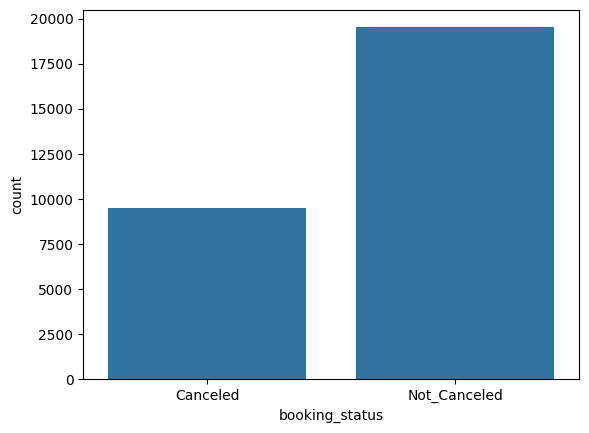

In [ ]:
len(train_index)
import seaborn as sns
import matplotlib.pyplot as plt

sns.countplot(data=pd.DataFrame({"booking_status": hotel_y}),
              x="booking_status")
plt.show()

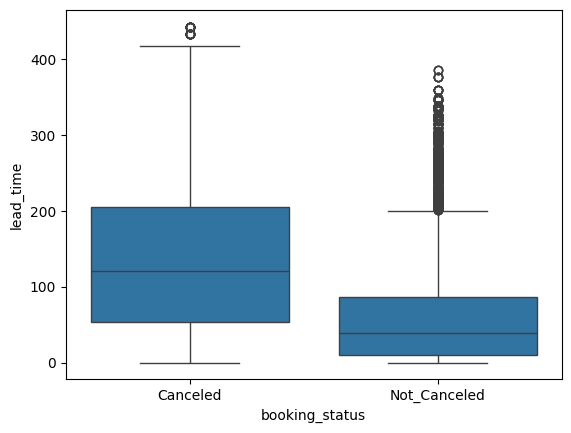

In [ ]:
sns.boxplot(
    x=hotel_y,
    y=hotel_X["lead_time"]
)
plt.show()

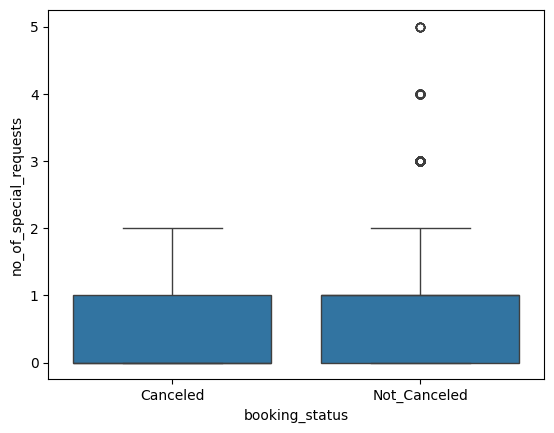

In [ ]:
sns.boxplot(
    x=hotel_y,
    y=hotel_X["no_of_special_requests"]
)
plt.show()

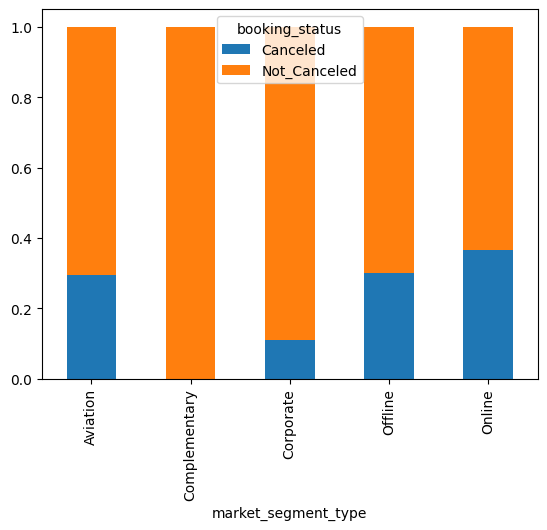

In [ ]:
pd.crosstab(
    df["market_segment_type"],
    df["booking_status"],
    normalize="index"
).plot(kind="bar", stacked=True)
plt.show()

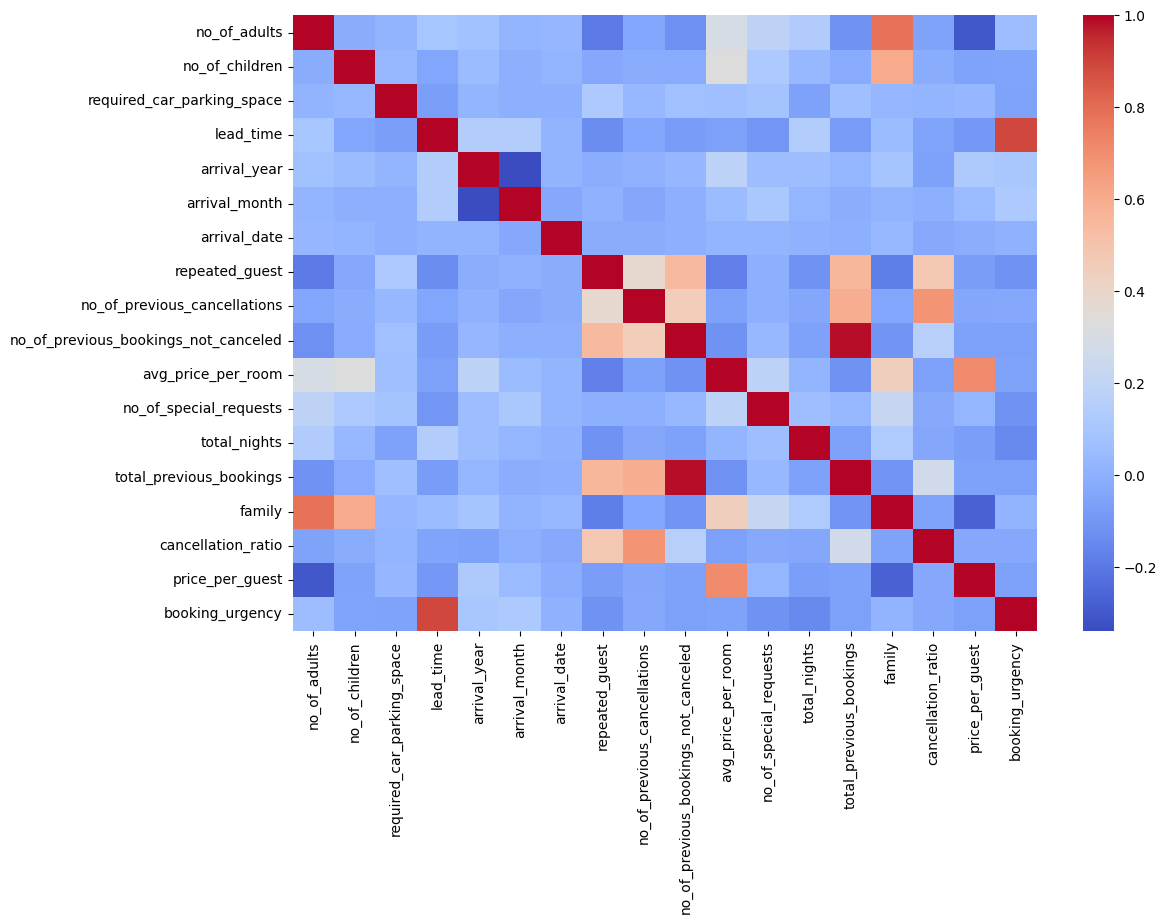

In [ ]:
plt.figure(figsize=(12,8))

sns.heatmap(
    hotel_X.select_dtypes(include="number").corr(),
    cmap="coolwarm",
    annot=False
)

plt.show()

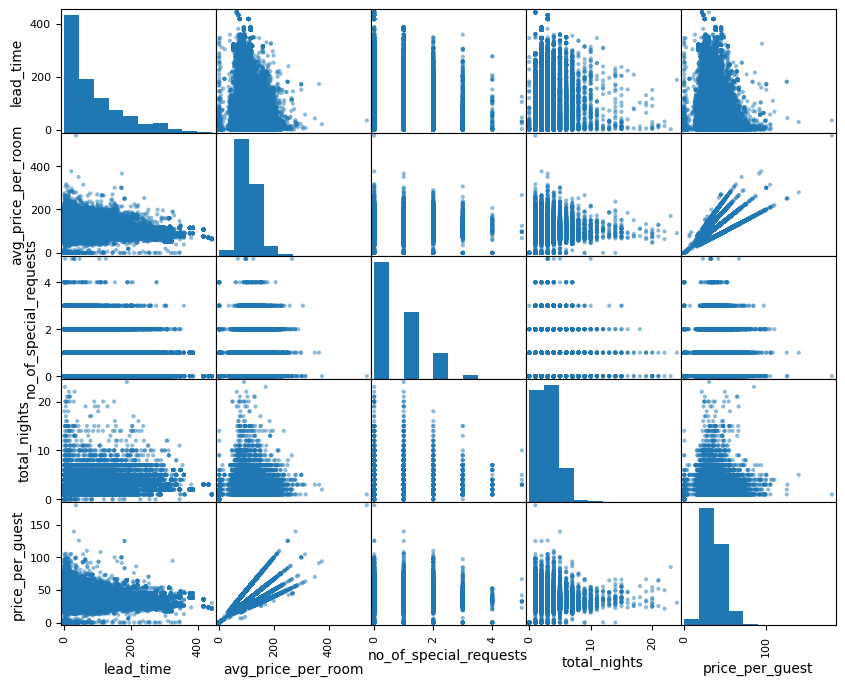

In [ ]:
from pandas.plotting import scatter_matrix

attributes = [
    "lead_time",
    "avg_price_per_room",
    "no_of_special_requests",
    "total_nights",
    "price_per_guest"
]

scatter_matrix(
    hotel_X[attributes],
    figsize=(10,8)
)

plt.show()

<Axes: xlabel='lead_time', ylabel='no_of_special_requests'>

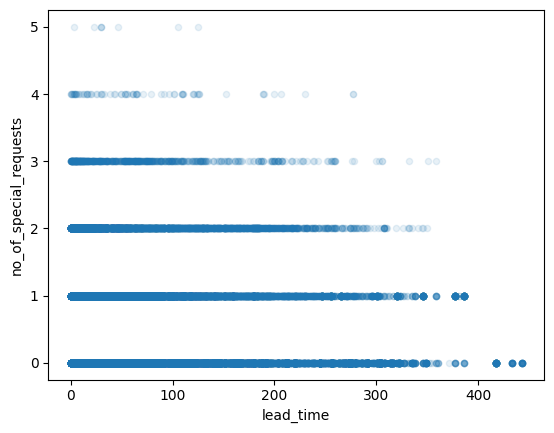

In [ ]:
df.plot(kind="scatter",x="lead_time",y="no_of_special_requests", alpha=0.1)

ValueError: s must be a scalar, or float array-like with the same size as x and y

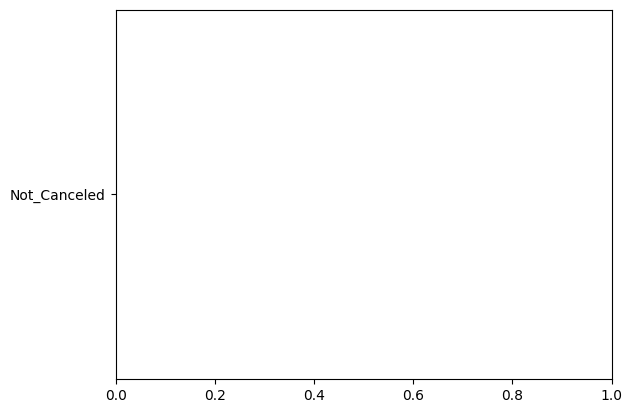

In [ ]:
plt.scatter(x=df["lead_time"],y=df["booking_status"], alpha=1.0,s=df['market_segment_type'])

<Axes: xlabel='lead_time', ylabel='avg_price_per_room'>

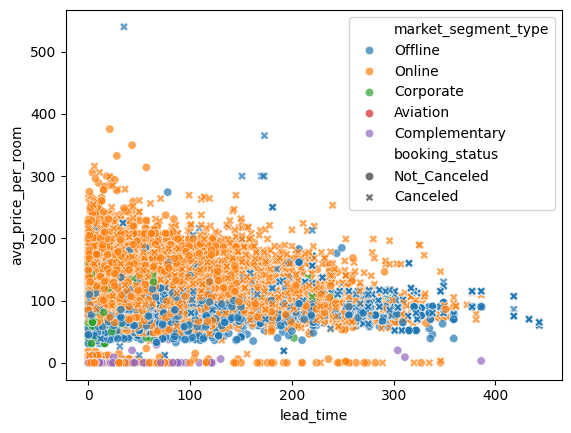

In [ ]:
import seaborn as sns

sns.scatterplot(
    data=df,
    x="lead_time",
    y="avg_price_per_room",
    hue="market_segment_type",
    style="booking_status",
    alpha=0.7
)

<Axes: xlabel='booking_status', ylabel='lead_time'>

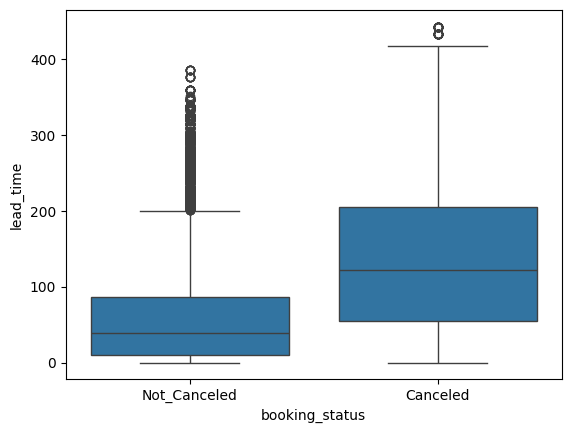

In [ ]:
sns.boxplot(
    x="booking_status",
    y="lead_time",
    data=df
)

<Axes: xlabel='booking_status', ylabel='no_of_special_requests'>

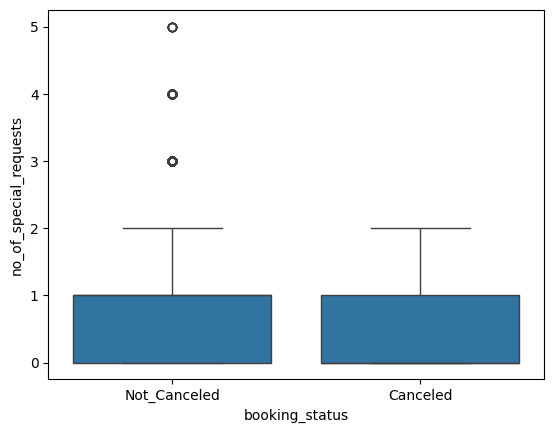

In [ ]:
sns.boxplot(
    x="booking_status",
    y="no_of_special_requests",
    data=df
)

<Axes: xlabel='market_segment_type'>

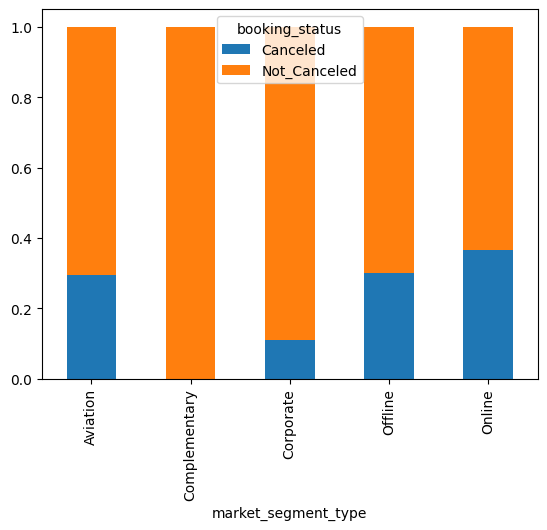

In [ ]:
pd.crosstab(
    df["market_segment_type"],
    df["booking_status"],
    normalize="index"
).plot(kind="bar", stacked=True)

In [ ]:
corr_matrix=df.corr(numeric_only=True)
corr_matrix[].sort_values(ascending=False)

KeyError: 'booking_status'

In [ ]:
df["type_of_meal_plan"] = df["type_of_meal_plan"].map({
"Meal Plan 1" :1,
"Not Selected":0,
"Meal Plan 2"	:2,
"Meal Plan 3":3

})

In [ ]:
df

,no_of_adults,no_of_children,no_of_weekend_nights,no_of_week_nights,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,repeated_guest,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,booking_status
0,2,0,1,2,1,0,1,224,2017,10,2,0,0,0,0,65.00,0,0
1,2,0,2,3,0,0,1,5,2018,11,6,1,0,0,0,106.68,1,0
2,1,0,2,1,1,0,1,1,2018,2,28,1,0,0,0,60.00,0,1
3,2,0,0,2,1,0,1,211,2018,5,20,1,0,0,0,100.00,0,1
4,2,0,1,1,0,0,1,48,2018,4,11,1,0,0,0,94.50,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,3,0,2,6,1,0,4,85,2018,8,3,1,0,0,0,167.80,1,0
36271,2,0,1,3,1,0,1,228,2018,10,17,1,0,0,0,90.95,2,1
36272,2,0,2,6,1,0,1,148,2018,7,1,1,0,0,0,98.39,2,0
36273,2,0,0,3,0,0,1,63,2018,4,21,1,0,0,0,94.50,0,1


In [ ]:
DF

NameError: name 'DF' is not defined

In [ ]:
cor_matrix=df.corr(numeric_only=True)
cor_matrix["booking_status"].sort_values(ascending=False)

,booking_status
booking_status,1.000000
lead_time,0.438538
arrival_year,0.179529
avg_price_per_room,0.142569
no_of_week_nights,0.092996
no_of_adults,0.086920
no_of_weekend_nights,0.061563
type_of_meal_plan,0.049374
no_of_children,0.033078
room_type_reserved,0.022986


In [ ]:
hotel = strat_train_set.copy()

hotel_labels = y.iloc[train_index].copy()

In [ ]:
hotel

,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,market_segment_type,...,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,total_nights,total_previous_bookings,family,cancellation_ratio,price_per_guest,booking_urgency
9078,2,0,Meal Plan 1,0,Room_Type 1,273,2018,5,13,Offline,...,0,0,95.00,0,3,0,2,0.0,31.666667,68.250000
36042,2,0,Meal Plan 1,0,Room_Type 1,158,2018,6,30,Online,...,0,0,90.95,1,4,0,2,0.0,30.316667,31.600000
5929,2,0,Meal Plan 1,0,Room_Type 1,59,2018,11,26,Online,...,0,0,93.60,1,3,0,2,0.0,31.200000,14.750000
6928,1,0,Meal Plan 1,0,Room_Type 1,5,2018,10,25,Aviation,...,0,0,95.00,0,2,0,1,0.0,47.500000,1.666667
34607,2,2,Meal Plan 1,0,Room_Type 6,54,2018,4,29,Online,...,0,0,187.85,0,6,0,4,0.0,37.570000,7.714286
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
6705,2,1,Meal Plan 1,0,Room_Type 4,91,2018,5,13,Online,...,0,0,140.40,0,3,0,3,0.0,35.100000,22.750000
2816,2,0,Meal Plan 1,0,Room_Type 1,63,2018,8,9,Online,...,0,0,144.10,0,3,0,2,0.0,48.033333,15.750000
5812,2,0,Meal Plan 1,0,Room_Type 1,16,2017,10,1,Online,...,0,0,107.00,0,2,0,2,0.0,35.666667,5.333333
4263,1,0,Meal Plan 2,0,Room_Type 1,273,2017,7,17,Offline,...,0,0,87.00,0,2,0,1,0.0,43.500000,91.000000


In [ ]:
hotel_labels

,booking_status
9078,Canceled
36042,Canceled
5929,Not_Canceled
6928,Not_Canceled
34607,Canceled
...,...
6705,Canceled
2816,Not_Canceled
5812,Not_Canceled
4263,Not_Canceled


In [ ]:
num_cols = [
    'no_of_adults',
    'no_of_children',
    'required_car_parking_space',
    'lead_time',
    'arrival_month',
    'arrival_date',
    'repeated_guest',
    'no_of_previous_cancellations',
    'no_of_previous_bookings_not_canceled',
    'avg_price_per_room',
    'no_of_special_requests',
    'total_nights',
    'family',
    'total_previous_bookings',
    'price_per_guest',
    'booking_urgency'
]
cat_cols = [
    'type_of_meal_plan',
    'room_type_reserved',
    'market_segment_type'
]

In [ ]:
X

,Booking_ID,no_of_adults,no_of_children,type_of_meal_plan,required_car_parking_space,room_type_reserved,lead_time,arrival_year,arrival_month,arrival_date,...,no_of_previous_cancellations,no_of_previous_bookings_not_canceled,avg_price_per_room,no_of_special_requests,total_nights,total_previous_bookings,family,cancellation_ratio,price_per_guest,booking_urgency
0,INN00001,2,0,Meal Plan 1,0,Room_Type 1,224,2017,10,2,...,0,0,65.00,0,3,0,2,0.0,21.666667,56.000000
1,INN00002,2,0,Not Selected,0,Room_Type 1,5,2018,11,6,...,0,0,106.68,1,5,0,2,0.0,35.560000,0.833333
2,INN00003,1,0,Meal Plan 1,0,Room_Type 1,1,2018,2,28,...,0,0,60.00,0,3,0,1,0.0,30.000000,0.250000
3,INN00004,2,0,Meal Plan 1,0,Room_Type 1,211,2018,5,20,...,0,0,100.00,0,2,0,2,0.0,33.333333,70.333333
4,INN00005,2,0,Not Selected,0,Room_Type 1,48,2018,4,11,...,0,0,94.50,0,2,0,2,0.0,31.500000,16.000000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
36270,INN36271,3,0,Meal Plan 1,0,Room_Type 4,85,2018,8,3,...,0,0,167.80,1,8,0,3,0.0,41.950000,9.444444
36271,INN36272,2,0,Meal Plan 1,0,Room_Type 1,228,2018,10,17,...,0,0,90.95,2,4,0,2,0.0,30.316667,45.600000
36272,INN36273,2,0,Meal Plan 1,0,Room_Type 1,148,2018,7,1,...,0,0,98.39,2,8,0,2,0.0,32.796667,16.444444
36273,INN36274,2,0,Not Selected,0,Room_Type 1,63,2018,4,21,...,0,0,94.50,0,3,0,2,0.0,31.500000,15.750000


In [ ]:
y

,booking_status
0,Not_Canceled
1,Not_Canceled
2,Canceled
3,Canceled
4,Canceled
...,...
36270,Not_Canceled
36271,Canceled
36272,Not_Canceled
36273,Canceled


In [ ]:

hotel_y=hotel_y.map({
    "Not_Canceled": 0,
    "Canceled": 1
})



,booking_status
9078,1
36042,1
5929,0
6928,0
34607,1
...,...
6705,1
2816,0
5812,0
4263,0


In [ ]:
hotel_y

,booking_status
9078,1
36042,1
5929,0
6928,0
34607,1
...,...
6705,1
2816,0
5812,0
4263,0


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

num_pipeline = Pipeline([
    ("scaler", StandardScaler())
])
from sklearn.preprocessing import OneHotEncoder

cat_pipeline = Pipeline([
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])



In [ ]:
from sklearn.compose import ColumnTransformer

preprocessor = ColumnTransformer([
    ("num", num_pipeline, num_cols),
    ("cat", cat_pipeline, cat_cols)
])

In [ ]:
hotel_y.value_counts()

,count
booking_status,
0,19512
1,9508


In [ ]:
hotel_prepared = preprocessor.fit_transform(hotel)
hotel_prepared

array([[ 0.2955342 , -0.26033883, -0.18033232, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.2955342 , -0.26033883, -0.18033232, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.2955342 , -0.26033883, -0.18033232, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.2955342 , -0.26033883, -0.18033232, ...,  0.        ,
         0.        ,  1.        ],
       [-1.63131428, -0.26033883, -0.18033232, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.2955342 ,  2.22241924, -0.18033232, ...,  0.        ,
         0.        ,  1.        ]])

In [ ]:
hotel_prepared.shape

(29020, 32)

In [ ]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000)

model.fit(hotel_prepared, hotel_y)

LogisticRegression(max_iter=1000)

In [ ]:
model.score(hotel_prepared, hotel_y)

0.8073053066850447

In [ ]:
predictions = model.predict(hotel_prepared)

In [ ]:
some_data=hotel.iloc[:5]
some_labels=hotel_y.iloc[:5]
some_data_prepared=preprocessor.transform(some_data)
prediction=model.predict(some_data_prepared)

In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(hotel_y, predictions)

0.8073053066850447

In [ ]:
from sklearn.metrics import classification_report

print(classification_report(
    hotel_y,
    predictions
))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86     19512
           1       0.74      0.63      0.68      9508

    accuracy                           0.81     29020
   macro avg       0.79      0.76      0.77     29020
weighted avg       0.80      0.81      0.80     29020



In [ ]:
from sklearn.metrics import confusion_matrix

confusion_matrix(
    hotel_y,
    predictions
)

array([[17465,  2047],
       [ 3545,  5963]])

In [ ]:
hotel_labels

,booking_status
9078,Canceled
36042,Canceled
5929,Not_Canceled
6928,Not_Canceled
34607,Canceled
...,...
6705,Canceled
2816,Not_Canceled
5812,Not_Canceled
4263,Not_Canceled


In [ ]:
from sklearn.metrics import accuracy_score

accuracy_score(hotel_y, predictions)

0.8073053066850447

In [ ]:
from sklearn.model_selection import cross_val_score

scores = cross_val_score(
    model,
    hotel_prepared,
    hotel_y,
    cv=5,
    scoring="accuracy"
)

print(scores)
print(scores.mean())
print(scores.std())

[0.81323225 0.81030324 0.80237767 0.80392833 0.8015162 ]
0.8062715368711233
0.004646984086766321


In [ ]:
hotel_prepared

array([[ 0.2955342 , -0.26033883, -0.18033232, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.2955342 , -0.26033883, -0.18033232, ...,  0.        ,
         0.        ,  1.        ],
       [ 0.2955342 , -0.26033883, -0.18033232, ...,  0.        ,
         0.        ,  1.        ],
       ...,
       [ 0.2955342 , -0.26033883, -0.18033232, ...,  0.        ,
         0.        ,  1.        ],
       [-1.63131428, -0.26033883, -0.18033232, ...,  0.        ,
         1.        ,  0.        ],
       [ 0.2955342 ,  2.22241924, -0.18033232, ...,  0.        ,
         0.        ,  1.        ]])

In [ ]:
from sklearn.metrics import precision_score , recall_score ,f1_score ,roc_curve ,roc_auc_score

precision_score(
    hotel_y,
    predictions
)

0.7444444444444445

In [ ]:
recall_score(
    hotel_y,
    predictions
)

0.6271560790912916

In [ ]:
f1_score(
    hotel_y,
    predictions
)

0.6807854777942688

In [ ]:
fpr , tpr , thresholds = roc_curve(
    hotel_y,
    predictions
)

In [ ]:
def plot_roc_curve(fpr, tpr,lable=None):
    plt.plot(fpr, tpr, color="orange", label="ROC")
    plt.plot([0, 1], [0, 1], color="darkblue", linestyle="--")
    plt.xlabel("False Positive Rate")
    plt.ylabel("True Positive Rate")
    plt.title("ROC Curve")
    plt.legend()
    plt.show()

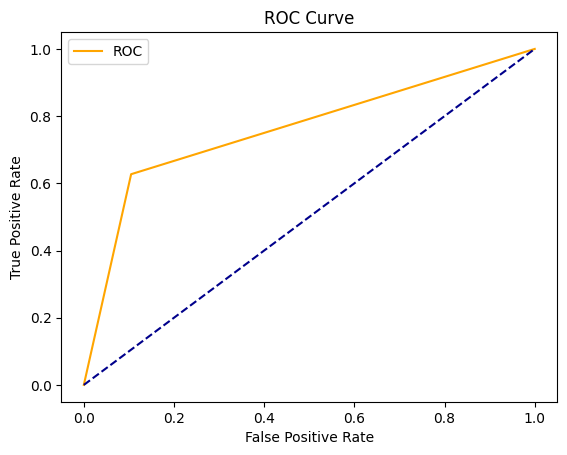

In [ ]:
plot_roc_curve(fpr, tpr)

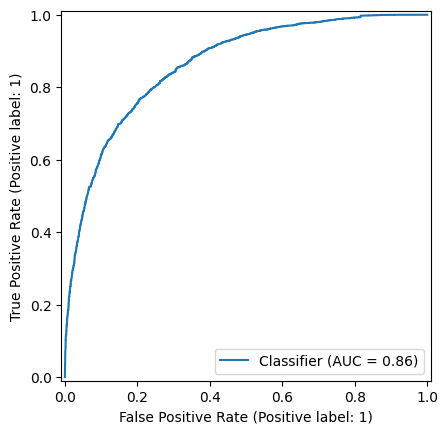

In [ ]:
from sklearn.metrics import RocCurveDisplay

y_scores = model.predict_proba(hotel_prepared)[:,1]

RocCurveDisplay.from_predictions(
    hotel_y,
    y_scores
)